In [1]:
#Import neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Load data
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

# Filter only first innings data
deliveries = deliveries[deliveries['inning'] == 1]

# Merge total runs per match (1st innings only)
innings_total = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
innings_total.columns = ['match_id', 'total_score']

# Merge metadata
match_features = matches[['id', 'season', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision']]
data = pd.merge(innings_total, match_features, left_on='match_id', right_on='id')

# Drop duplicates and missing
data.drop_duplicates(inplace=True)
data.dropna(inplace=True)

# Convert 'season' column from '2007/08' format to an integer (e.g., 2007)
data['season'] = data['season'].apply(lambda x: int(x.split('/')[0]))

# Create additional features (e.g., average runs per over)
data['runs_per_over'] = data['total_score'] / 20  # assuming 20 overs in the first innings

# Convert total_score to categorical bins
bins = [0, 120, 140, 160, 180, 200, np.inf]
labels = ['<120', '120-139', '140-159', '160-179', '180-199', '200+']
data['score_class'] = pd.cut(data['total_score'], bins=bins, labels=labels)

# Encode categorical features
encoder = LabelEncoder()
for col in ['city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'score_class']:
    data[col] = encoder.fit_transform(data[col])

# Feature selection
X = data[['season', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'runs_per_over']]
y = data['score_class']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train classifier with Random Forest
clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# Predict and calculate metrics
y_pred = clf.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=1)
recall = recall_score(y_test, y_pred, average='macro', zero_division=1)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=1)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.97
Precision: 0.98
Recall: 0.97
F1 Score: 0.98


<Figure size 800x600 with 0 Axes>

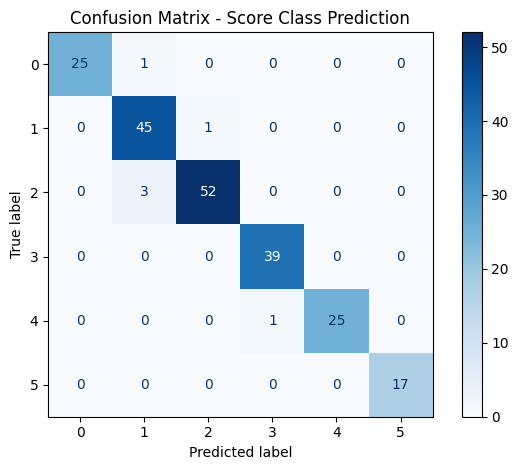

In [2]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Score Class Prediction")
plt.grid(False)
plt.tight_layout()
plt.show()

C:\Users\sanju\AppData\Local\Temp\ipykernel_26376\3474768812.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


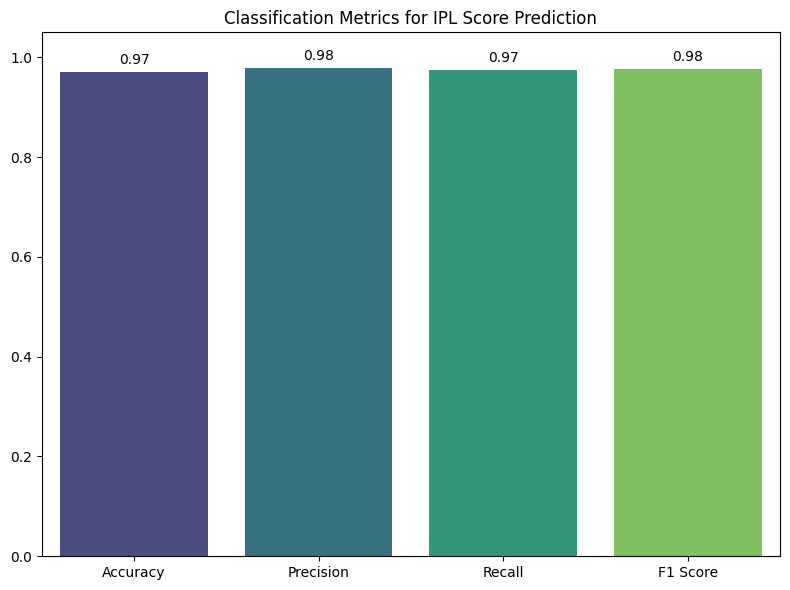

In [3]:
# Metric Visualization
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 6))
sns.barplot(x=metrics, y=values, palette='viridis')
for i, value in enumerate(values):
    plt.text(i, value + 0.01, f"{value:.2f}", ha='center', va='bottom')

plt.title("Classification Metrics for IPL Score Prediction")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [4]:
#Model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy*100:.2f} %")

Overall Model Accuracy: 97.13 %


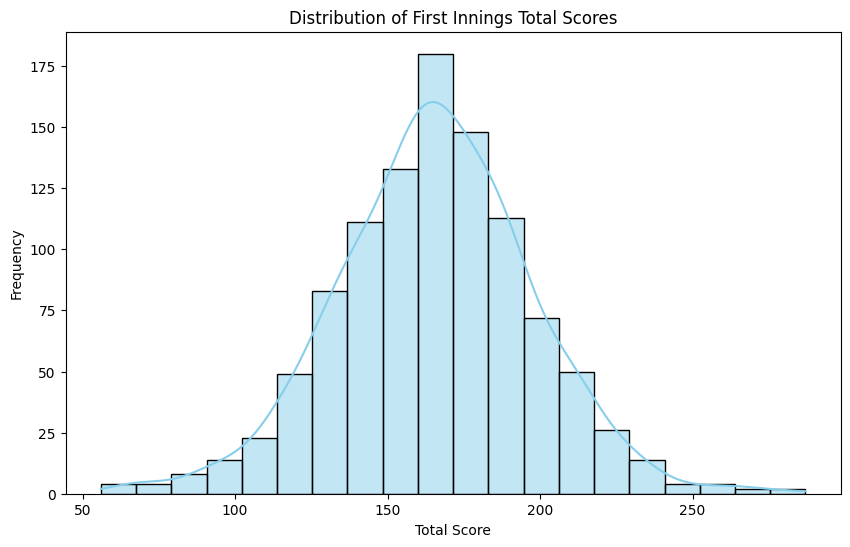

In [5]:
#Distribution of First Innings Total Scores
plt.figure(figsize=(10, 6))
sns.histplot(data['total_score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of First Innings Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.show()

C:\Users\sanju\AppData\Local\Temp\ipykernel_26376\3316388212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score_class', data=data, palette='Set2')


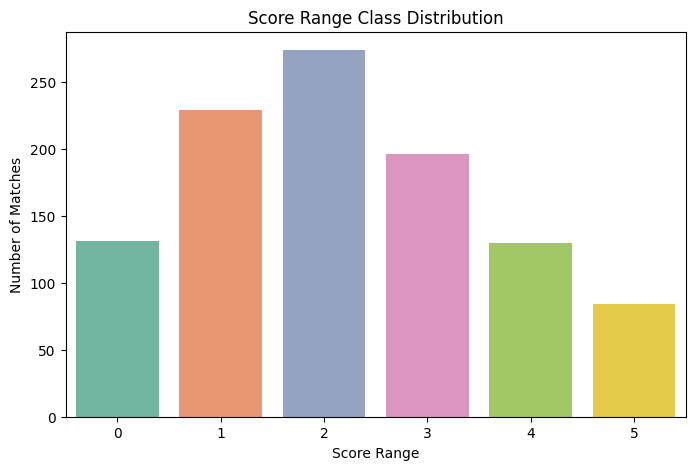

In [6]:
#Score Range Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='score_class', data=data, palette='Set2')
plt.title('Score Range Class Distribution')
plt.xlabel('Score Range')
plt.ylabel('Number of Matches')
plt.show()

C:\Users\sanju\AppData\Local\Temp\ipykernel_26376\1192829168.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_score', y='venue', data=venue_avg_score, palette='viridis')


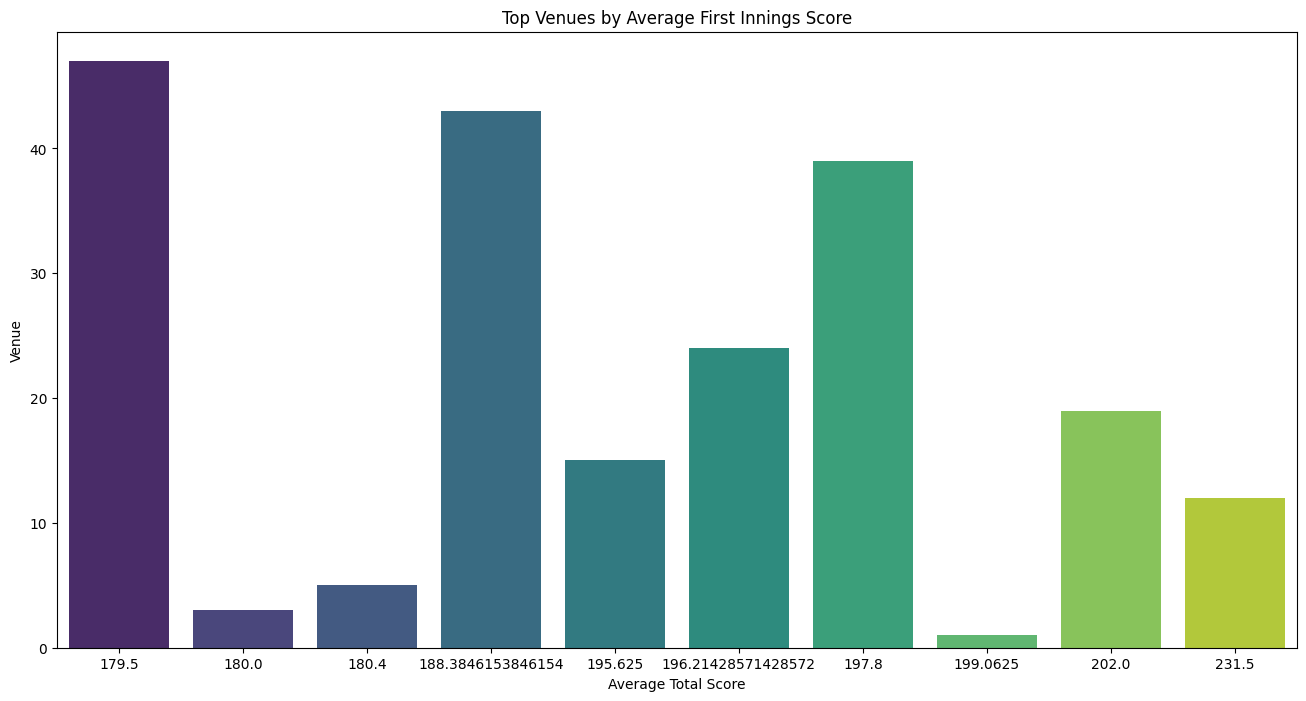

In [7]:
#Top Venues by Average First Innings Score
venue_avg_score = data.groupby('venue')['total_score'].mean().reset_index()
venue_avg_score = venue_avg_score.sort_values(by='total_score', ascending=False).head(10)
plt.figure(figsize=(16, 8))
sns.barplot(x='total_score', y='venue', data=venue_avg_score, palette='viridis')
plt.title('Top Venues by Average First Innings Score')
plt.xlabel('Average Total Score')
plt.ylabel('Venue')
plt.show()

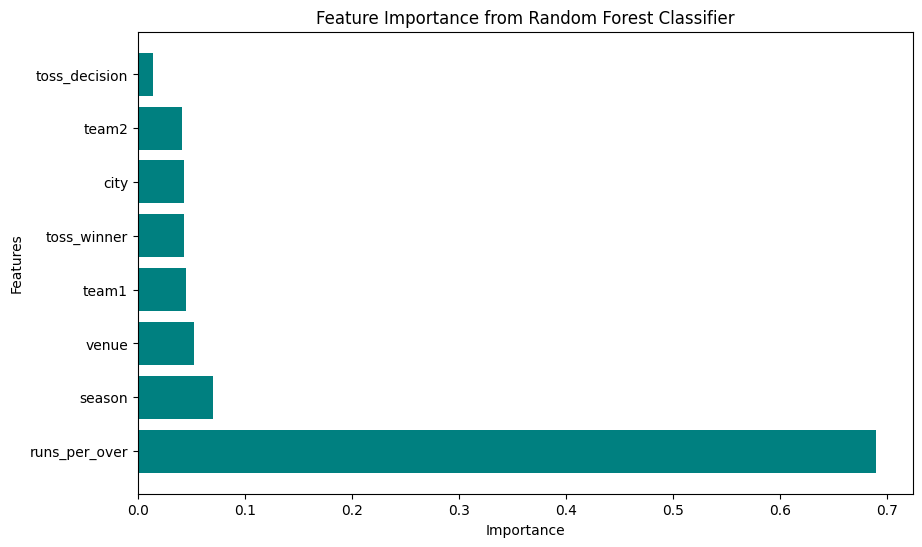

In [8]:
#Feature Importance from Random Forest Classifier
plt.figure(figsize=(10, 6))
feature_importances = clf.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]
plt.barh(np.array(X.columns)[sorted_idx], feature_importances[sorted_idx], color='teal')
plt.title('Feature Importance from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()